In [1]:
from pathlib import Path

import pandas as pd

In [10]:
CLEAN_DATA_PATH = (
    Path.cwd().parent
    /"data"
    /"clean"
    /"combined_clean_data.csv"
)

df_model = pd.read_csv(CLEAN_DATA_PATH)

print("Dataset shape",df_model.shape)
print("Columns",df_model.columns.tolist())

display(df_model.head())

Dataset shape (83444, 2)
Columns ['text', 'label']


,text,label
0,ounce feather bowl hummingbird opec moment ala...,1
1,wulvob get your medircations online qnb ikud v...,1
2,computer connection from cnn com wednesday es...,0
3,university degree obtain a prosperous future m...,1
4,thanks for all your answers guys i know i shou...,0


In [12]:
# creating feature
x = df_model["text"]
y = df_model["label"]

In [14]:
from sklearn.model_selection import train_test_split

In [16]:
x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [20]:
print(f"Training email: {len(x_train)}")
print(f"Testing email:{len(x_test)}")

print(
    f"Training spam percentage: {round((y_train == 1).mean()*100,2)}"
)

print(
    f"Testing spam percentage: {round((y_test == 1).mean()*100,2)}"
)

Training email: 66755
Testing email:16689
Training spam percentage: 52.62
Testing spam percentage: 52.62


In [27]:
total_emails = len(x_train) + len(x_test)

print(
    "Training data percentage:",
    round((len(x_train) / total_emails * 100),2)
)

print(
    "Testing data percentage:",
    round((len(x_test) / total_emails * 100),2)
)

Training data percentage: 80.0
Testing data percentage: 20.0


In [28]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline

In [29]:
naive_bayes_pipeline = Pipeline([
    (
    "tfidf",
    TfidfVectorizer(max_features=10_000)
    ),
    (
        "model",
        MultinomialNB()
    )
])

In [30]:
naive_bayes_pipeline.fit(
    x_train,
    y_train
)

print(f"Model trained succesfully")

Model trained succesfully


In [32]:
y_pred_nb = naive_bayes_pipeline.predict(x_test)

print("Predictions created:", len(y_pred_nb))
print("Testing email:", len(x_test))

Predictions created: 16689
Testing email: 16689


In [34]:
prediction_sample = pd.DataFrame({
    "email_text": x_test.iloc[:10].values,
    "actual_label": y_test.iloc[:10].values,
    "predicted_label": y_pred_nb[:10]
})

display(prediction_sample)

,email_text,actual_label,predicted_label
0,alert name bush lebanese minister pleads for m...,0,0
1,louise -\nhere is the start to the profile for...,0,0
2,anatrim an extremely powerful lose flesh blend...,1,1
3,there's no special method just create a list i...,0,0
4,vip r e p l i c a w a t c h e s if you are loo...,1,1
5,this message has been sent to you by elist mat...,1,1
6,shoot your wad all over her face .\nthese girl...,1,1
7,night with haspinger for her father's headquar...,1,1
8,i am pleased to announce the following changes...,0,0
9,"state . . .\ngray david , loretta lynch , and ...",0,0


In [35]:
# now prediction is done , now lets test model accuracy
from sklearn.metrics import accuracy_score

In [36]:
nb_accuracy = accuracy_score(
    y_test,
    y_pred_nb
)

print(
    f"Naive bayes pipline : {nb_accuracy*100:.2f}%"
)

Naive bayes pipline : 97.00%


!Around 500 variables are predected wrongly

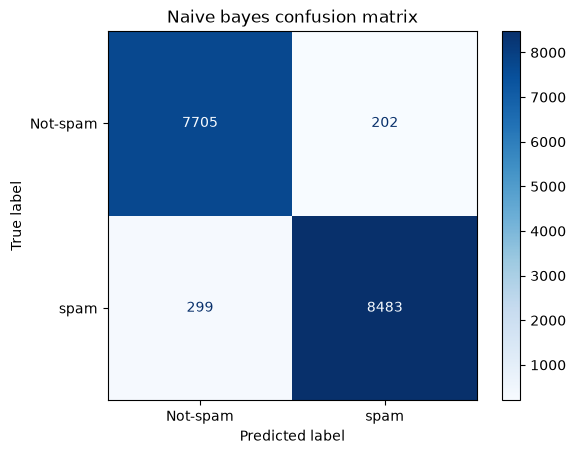

In [37]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

nb_confusion_matrix = confusion_matrix(
    y_test,
    y_pred_nb
)

display= ConfusionMatrixDisplay(
    confusion_matrix= nb_confusion_matrix,display_labels=["Not-spam","spam"]
)

display.plot(cmap="Blues")
plt.title("Naive bayes confusion matrix")
plt.show()

In [38]:
from sklearn.metrics import classification_report

print(classification_report(

    y_test,
    y_pred_nb,
    target_names=["Not-spam","spam"]
)
)

              precision    recall  f1-score   support

    Not-spam       0.96      0.97      0.97      7907
        spam       0.98      0.97      0.97      8782

    accuracy                           0.97     16689
   macro avg       0.97      0.97      0.97     16689
weighted avg       0.97      0.97      0.97     16689



Trying logistic regression

In [39]:
from sklearn.linear_model import LogisticRegression

In [40]:
logistic_pipeline = Pipeline([
    (
        "tfidf",
        TfidfVectorizer(max_features=10_000)
    ),
    (
        "model",
        LogisticRegression(
            max_iter=1000,
            random_state=42
        )
    )
])

logistic_pipeline.fit(x_train, y_train)
print("Logistic Regression trained successfully")

Logistic Regression trained successfully


In [41]:
y_pred_lr = logistic_pipeline.predict(x_test)
print("Predictions created:", len(y_pred_lr))

Predictions created: 16689


In [42]:
lr_accuracy = accuracy_score(y_test,y_pred_lr)

print(f"LogisticRegression accuraccy:{lr_accuracy*100:.2f}%")

print(
    classification_report(
        y_test,
        y_pred_lr,
        target_names=["not-spam","spam"],
        digits=4
    )
)


LogisticRegression accuraccy:98.38%
              precision    recall  f1-score   support

    not-spam     0.9881    0.9776    0.9828      7907
        spam     0.9800    0.9894    0.9847      8782

    accuracy                         0.9838     16689
   macro avg     0.9841    0.9835    0.9838     16689
weighted avg     0.9839    0.9838    0.9838     16689



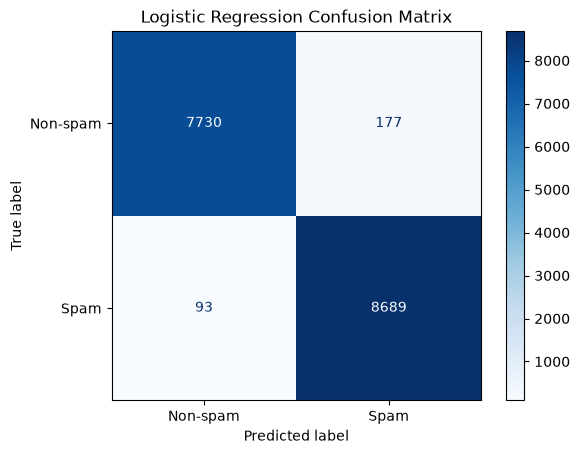

In [44]:
lr_matrix = confusion_matrix(y_test, y_pred_lr)

lr_plot = ConfusionMatrixDisplay(
    confusion_matrix=lr_matrix,
    display_labels=["Non-spam", "Spam"]
)

lr_plot.plot(cmap="Blues")
plt.title("Logistic Regression Confusion Matrix")
plt.show()

In [47]:
# testing manual mode
subject = "Project meeting tomorrow"
body = "Hi, please bring your notebook for our project discussion at 10 AM."

email_text = subject + "\n" + body

prediction = logistic_pipeline.predict([email_text])[0]

if prediction == 1:
    print("Prediction: Spam")
else:
    print("Prediction: Non-spam")

Prediction: Non-spam


In [48]:
import joblib

MODEL_PATH = (
    Path.cwd().parent
    /"artifact"
    /"spam_detection_pipline.joblib"
)

MODEL_PATH.parent.mkdir(parents=True, exist_ok=True)
joblib.dump(logistic_pipeline, MODEL_PATH)
print(f"Pipeline saved at: {MODEL_PATH.resolve()}")

Pipeline saved at: /home/kavya/Documents/Studies/Bca/Projects/Spam_detection/Python-services/artifact/spam_detection_pipline.joblib


In [ ]:
# lets try loading the model and see if its working
loaded_pipeline = joblib.load(MODEL_PATH)

result = loaded_pipeline.predict([
    "Please bring your notebook to tomorrow's project meeting."
])

print("Prediction:", result[0])

Prediction: 0
